In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport

In [5]:
target_col = 'Diabetes_012' 

selected_features = [
    target_col,             
    'HighBP',             
    'HighChol',            
    'BMI',                 
    'Smoker',              
    'HeartDiseaseorAttack', 
    'PhysActivity',     
    'GenHlth',            
    'MentHlth',          
    'PhysHlth',            
    'DiffWalk',             
    'Age'                
]

In [4]:
input_file_path = "../../datasets/raw/diabetes_012_health_indicators_BRFSS2015.csv" 
try:
    print(f"Đang đọc dữ liệu từ {input_file_path} ---")
    data = pd.read_csv(input_file_path, sep=",", encoding='utf-8')
    print(f"Shape ban đầu: {data.shape}")
except FileNotFoundError:
    print(f"LỖI: Không tìm thấy file '{input_file_path}'. Vui lòng kiểm tra lại đường dẫn.")

Đang đọc dữ liệu từ ../../datasets/raw/diabetes_012_health_indicators_BRFSS2015.csv ---
Shape ban đầu: (253680, 22)


In [6]:
available_cols = [col for col in selected_features if col in data.columns]
if len(available_cols) < len(selected_features):
    print("Cảnh báo: Một số cột không tìm thấy trong dữ liệu gốc!")
    print(f"Các cột bị thiếu: {set(selected_features) - set(available_cols)}")

data_filtered = data[available_cols].copy()
print(f"Shape sau khi chọn feature: {data_filtered.shape}")

Shape sau khi chọn feature: (253680, 12)


In [ ]:
# 4. Xử lý làm sạch 
# 4.1. Kiểm tra và xóa dữ liệu trùng lặp (Duplicate)
duplicates = data_filtered.duplicated().sum()
print(f"Phát hiện {duplicates} dòng trùng lặp. Đang tiến hành xóa...")
data_filtered.drop_duplicates(inplace=True)
print(f"Shape sau khi xóa trùng lặp: {data_filtered.shape}")

# 4.2. Kiểm tra dữ liệu null
print("\n--- Kiểm tra giá trị Null ---")
print(data_filtered.isnull().sum())

Phát hiện 113397 dòng trùng lặp. Đang tiến hành xóa...
Shape sau khi xóa trùng lặp: (140283, 12)

--- Kiểm tra giá trị Null ---
Diabetes_012            0
HighBP                  0
HighChol                0
BMI                     0
Smoker                  0
HeartDiseaseorAttack    0
PhysActivity            0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Age                     0
dtype: int64


In [10]:
data_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140283 entries, 0 to 253678
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          140283 non-null  float64
 1   HighBP                140283 non-null  float64
 2   HighChol              140283 non-null  float64
 3   BMI                   140283 non-null  float64
 4   Smoker                140283 non-null  float64
 5   HeartDiseaseorAttack  140283 non-null  float64
 6   PhysActivity          140283 non-null  float64
 7   GenHlth               140283 non-null  float64
 8   MentHlth              140283 non-null  float64
 9   PhysHlth              140283 non-null  float64
 10  DiffWalk              140283 non-null  float64
 11  Age                   140283 non-null  float64
dtypes: float64(12)
memory usage: 13.9 MB



Thống kê mô tả (Describe)
        Diabetes_012         HighBP       HighChol            BMI  \
count  140283.000000  140283.000000  140283.000000  140283.000000   
mean        0.446098       0.512058       0.489503      29.699515   
std         0.813592       0.499856       0.499892       7.748598   
min         0.000000       0.000000       0.000000      12.000000   
25%         0.000000       0.000000       0.000000      25.000000   
50%         0.000000       1.000000       0.000000      28.000000   
75%         0.000000       1.000000       1.000000      33.000000   
max         2.000000       1.000000       1.000000      98.000000   

              Smoker  HeartDiseaseorAttack   PhysActivity        GenHlth  \
count  140283.000000         140283.000000  140283.000000  140283.000000   
mean        0.495677              0.145299       0.664393       2.894321   
std         0.499983              0.352403       0.472204       1.097122   
min         0.000000              0.000000     

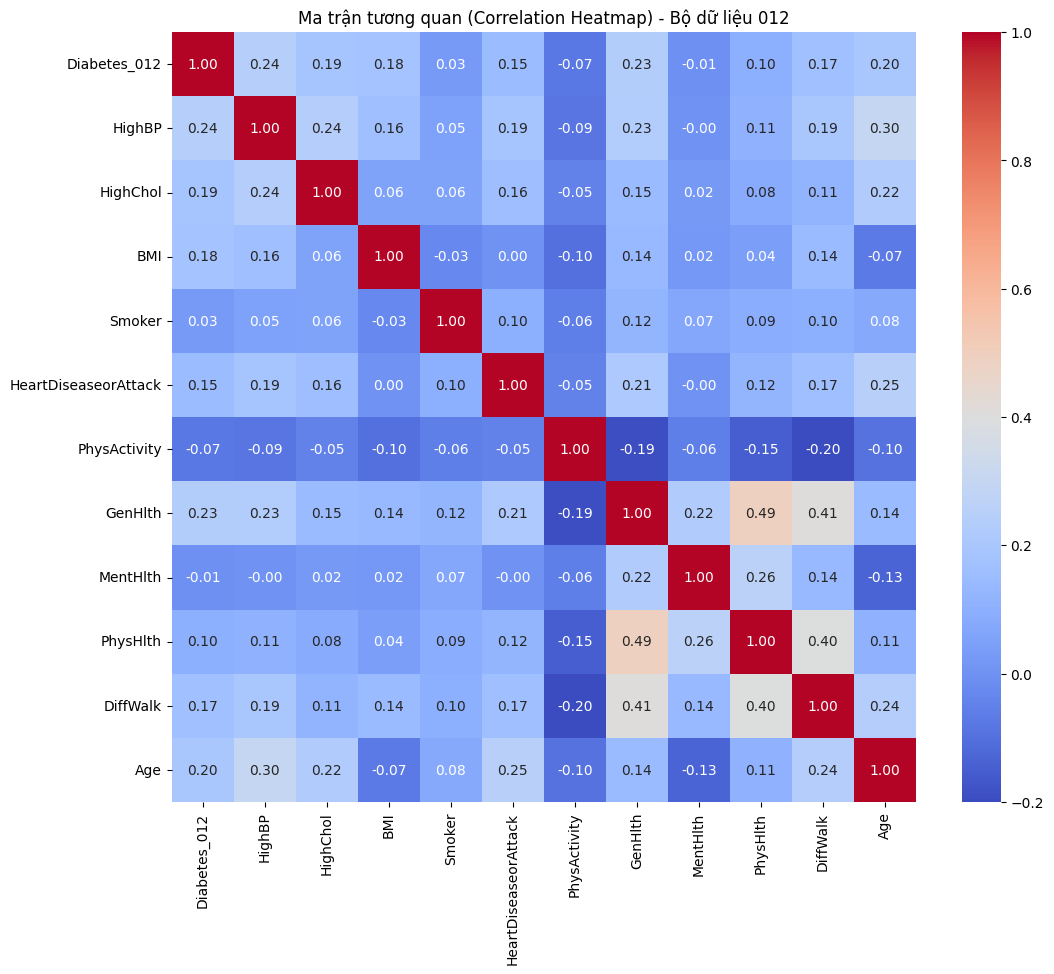

In [8]:
# 5. Phân tích cơ bản (EDA)
print("\nThống kê mô tả (Describe)")
print(data_filtered.describe())

# 5.1 Vẽ Heatmap tương quan (Correlation)
plt.figure(figsize=(12, 10))
sns.heatmap(data_filtered.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Ma trận tương quan (Correlation Heatmap) - Bộ dữ liệu 012")
plt.show()


--- Thống kê số lượng các lớp ---
Diabetes_012
0.0    106800
1.0      4386
2.0     29097
Name: count, dtype: int64

--- Tỷ lệ phần trăm ---
Diabetes_012
0.0    76.13%
1.0     3.13%
2.0    20.74%
Name: proportion, dtype: object


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13000\1856521518.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Diabetes_012', data=df, palette='viridis')


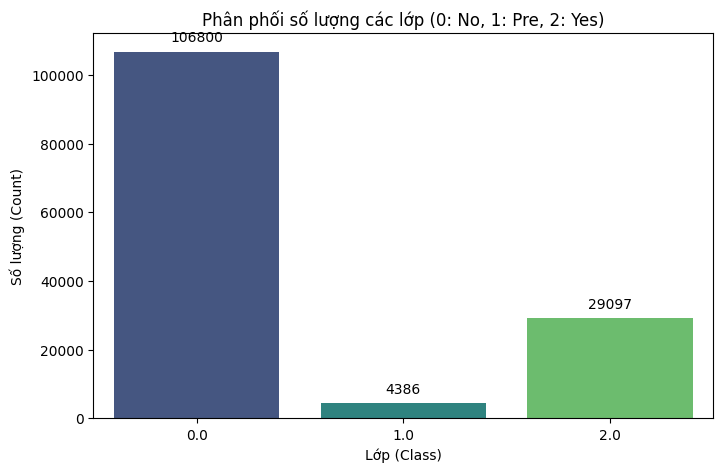

In [11]:
df = data_filtered

# 1. Thống kê số lượng
counts = df['Diabetes_012'].value_counts().sort_index()
print("--- Thống kê số lượng các lớp ---")
print(counts)

# 2. Tính tỷ lệ phần trăm
percentages = df['Diabetes_012'].value_counts(normalize=True).sort_index() * 100
print("\n--- Tỷ lệ phần trăm ---")
print(percentages.round(2).astype(str) + '%')

# 3. Vẽ biểu đồ minh họa
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Diabetes_012', data=df, palette='viridis')
plt.title('Phân phối số lượng các lớp (0: No, 1: Pre, 2: Yes)')
plt.xlabel('Lớp (Class)')
plt.ylabel('Số lượng (Count)')

# Hiển thị số trên đầu cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

In [13]:
output_filename = "../../datasets/processed/cdc_diabetes_012.csv"
data_filtered.to_csv(output_filename, index=False)
print(f"\n[HOÀN TẤT] Đã lưu bộ dữ liệu đã xử lý tại: {output_filename}")


[HOÀN TẤT] Đã lưu bộ dữ liệu đã xử lý tại: ../../datasets/processed/cdc_diabetes_012.csv
